In [14]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from quantum_cva.mc_benchmark.benchmark_utils import (
    simulate_S,
    price_grid_from_samples,
    discrete_probs_from_samples,
)
from quantum_cva.state_prep.qcbm.p_target import build_joint_target_from_P_bin
from quantum_cva.state_prep.qcbm.qcbm_utils import build_ansatz, make_cost, probs_from_params, metrics
from scipy.optimize import minimize

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Loading target probability distribution $p_{tg}(x)$

In [15]:
# Discretization parameters
n = 2
m = 2
N = 2**n  # number of price bins
M = 2**m  # number of time steps

In [16]:
# ============================================================
# 0) Reproducibility
# ============================================================
np.random.seed(123)
 
# ============================================================
# 1) Simulate realistic S(t) paths
# ============================================================
S0 = 1.0
r = 0.02
sigma = 0.25

t = np.array([0.0, 0.25, 0.5, 1.0, 2.0], dtype=float)  # length M+1 => M=4

n_paths = 50_000
Z = np.random.standard_normal(size=(n_paths, M))

S_by_time = simulate_S(S0=S0, mu=r, sigma=sigma, t=t, Z=Z)

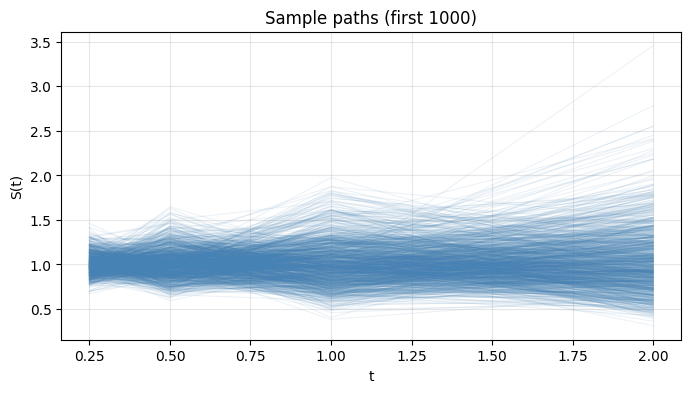

In [17]:
# Plot some sample paths and histogram at T
n_plot = 1000
S_plot = np.vstack([s[:n_plot] for s in S_by_time])

plt.figure(figsize=(8, 4))
for k in range(n_plot):
    plt.plot(t[1:], S_plot[:, k], color="steelblue", alpha=0.1, linewidth=0.8)
plt.title("Sample paths (first 1000)")
plt.xlabel("t")
plt.ylabel("S(t)")
plt.grid(True, alpha=0.3)
plt.show()

In [18]:
# ============================================================
# 2) Discretize prices: choose n so that N=2^n bins (power of two)
# ============================================================
n_sigma = 3.0

edges, grid_info = price_grid_from_samples(S_by_time, n=n, n_sigma=n_sigma)
print("Grid info:", grid_info)
print("edges length:", len(edges), "=> N bins:", len(edges) - 1)
assert (len(edges) - 1) == N

Grid info: [0.27296904 0.81890713 1.36484522 1.91078331]
edges length: 5 => N bins: 4


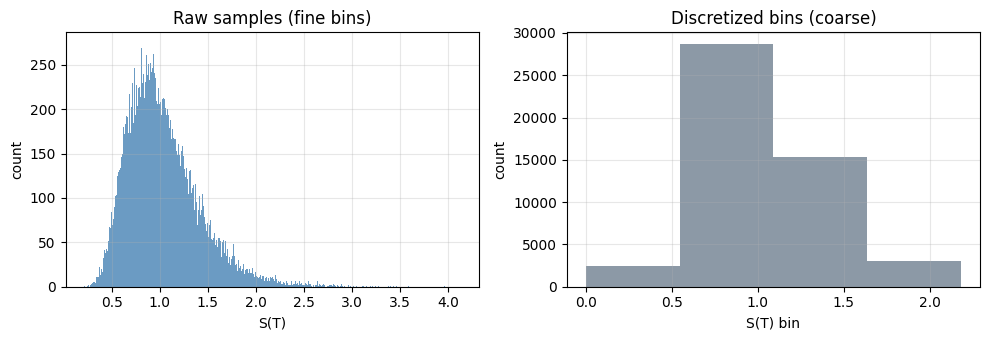

In [19]:
# ============================================================
# 2b) Histogram: raw vs discretized prices (loss of resolution)
# ============================================================
import matplotlib.pyplot as plt

t_idx = -1  # use final exposure date
samples = S_by_time[t_idx]

# Raw histogram (fine bins)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].hist(samples, bins=1000, color="steelblue", alpha=0.8)
axes[0].set_title("Raw samples (fine bins)")
axes[0].set_xlabel("S(T)")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

# Discretized histogram using the grid edges
counts, _ = np.histogram(samples, bins=edges)
bin_centers = 0.5 * (edges[:-1] + edges[1:])
bin_widths = edges[1:] - edges[:-1]
axes[1].bar(bin_centers, counts, width=bin_widths, color="slategray", alpha=0.8, align="center")
axes[1].set_title("Discretized bins (coarse)")
axes[1].set_xlabel("S(T) bin")
axes[1].set_ylabel("count")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [20]:
# ============================================================
# 3) Build conditional distributions P_bin[i,:] = P(s_bin | t_i)
# ============================================================
P_bin = np.zeros((M, N), dtype=float)
for i in range(M):
    P_bin[i, :] = discrete_probs_from_samples(S_by_time[i], edges)

assert P_bin.shape == (M, N)
assert np.all(P_bin >= -1e-15)
assert np.allclose(P_bin.sum(axis=1), 1.0, atol=1e-10)
print("P_bin OK. shape:", P_bin.shape)

P_bin OK. shape: (4, 4)


In [21]:
# ============================================================
# 4) Build joint target for QCBM 
#    p_tg(i,j) = P(t_i) P(s_j|t_i), with uniform P(t_i)=1/M by default
# ============================================================
tgt = build_joint_target_from_P_bin(P_bin, order="time_major") 

print("\n--- Joint target summary ---")
print(f"M={tgt.M} (m={tgt.m} qubits), N={tgt.N} (n={tgt.n} qubits)")
print("len(p_tg) =", tgt.p_tg.size, "(expected M*N =", tgt.M * tgt.N, ")")
print("sum(p_tg) =", tgt.p_tg.sum())

assert tgt.M == M
assert tgt.N == N
assert tgt.p_tg.ndim == 1
assert tgt.p_tg.size == M * N
assert abs(tgt.p_tg.sum() - 1.0) < 1e-12


--- Joint target summary ---
M=4 (m=2 qubits), N=4 (n=2 qubits)
len(p_tg) = 16 (expected M*N = 16 )
sum(p_tg) = 1.0


Joint target distribution:
$$
p_{tg}(x),
$$
a flatten vector with $2^{n + m}$ elements. So the register $x$ is written in the computational basis of $n + m$ qubits.

In [22]:
# ============================================================
# Print all computational basis states directly from p_tg
# ============================================================
# Sanity check: check dimensions of tgt are correct
ptg = tgt.p_tg
m = tgt.m      # time qubits
n = tgt.n      # price qubits
M = tgt.M
N = tgt.N

def to_bits(x, L):
    return format(x, f"0{L}b")

print("Probability distribution over computational basis states (quantum - friendly):")

for x, prob in enumerate(ptg):
    # Binary representation of the full register
    bits = to_bits(x, m + n)

    # Decode indices according to time_major convention
    i = x // N          # time index
    j = x % N           # price-bin index

    bits_time  = bits[:m]
    bits_price = bits[m:]

    print(
        f"|{bits}>  "
        f"(t_{i+1}, s_{j})  "
        f"P = {prob:.6e}"
    )


Probability distribution over computational basis states (quantum - friendly):
|0000>  (t_1, s_0)  P = 0.000000e+00
|0001>  (t_1, s_1)  P = 1.915800e-01
|0010>  (t_1, s_2)  P = 5.841000e-02
|0011>  (t_1, s_3)  P = 1.000000e-05
|0100>  (t_2, s_0)  P = 8.000000e-05
|0101>  (t_2, s_1)  P = 1.749200e-01
|0110>  (t_2, s_2)  P = 7.441500e-02
|0111>  (t_2, s_3)  P = 5.850000e-04
|1000>  (t_3, s_0)  P = 2.106685e-03
|1001>  (t_3, s_1)  P = 1.606585e-01
|1010>  (t_3, s_2)  P = 8.202562e-02
|1011>  (t_3, s_3)  P = 5.209167e-03
|1100>  (t_4, s_0)  P = 1.210477e-02
|1101>  (t_4, s_1)  P = 1.449233e-01
|1110>  (t_4, s_2)  P = 7.749686e-02
|1111>  (t_4, s_3)  P = 1.547508e-02


---

## QCBM ansatz definition & training

In [24]:
# Rename discretization variables to enhance quantum readability
num_qubits_price = n
num_qubits_time = m
num_qubits = num_qubits_price + num_qubits_time

In [37]:
# Ansatz definition
qc, theta = build_ansatz(n_qubits=num_qubits, name="G_p")
cost = make_cost(qc, theta, ptg, eps=1e-12)

print(qc.draw(output="text", fold=120))

     ┌──────────────┐┌──────────────┐┌────────────────┐┌────────────────┐┌─────────────────┐                   »
q_0: ┤ Rx(theta[0]) ├┤ Rz(theta[1]) ├┤0               ├┤0               ├┤0                ├───────────────────»
     ├──────────────┤├──────────────┤│  Rxx(theta[8]) ││                ││                 │┌─────────────────┐»
q_1: ┤ Rx(theta[2]) ├┤ Rz(theta[3]) ├┤1               ├┤  Rxx(theta[9]) ├┤                 ├┤0                ├»
     ├──────────────┤├──────────────┤└────────────────┘│                ││  Rxx(theta[10]) ││  Rxx(theta[11]) │»
q_2: ┤ Rx(theta[4]) ├┤ Rz(theta[5]) ├──────────────────┤1               ├┤                 ├┤1                ├»
     ├──────────────┤├──────────────┤                  └────────────────┘│                 │└─────────────────┘»
q_3: ┤ Rx(theta[6]) ├┤ Rz(theta[7]) ├────────────────────────────────────┤1                ├───────────────────»
     └──────────────┘└──────────────┘                                    └─────────────────┘    

In [39]:
# Ansatz training
x0 = 0.01 * np.random.randn(len(theta))

res = minimize(
    cost,
    x0=x0,
    method="COBYLA",
    options={"maxiter": 3000, "rhobeg": 0.5, "disp": True},
)

theta_star = res.x
p_star = probs_from_params(qc, theta, theta_star)

print("Final cost:", res.fun)
print("L1 error:", np.sum(np.abs(p_star - ptg)))
print("KL(ptg || p_star) clipped:",
      np.sum(ptg * np.log(np.maximum(ptg,1e-12)/np.maximum(p_star,1e-12))))

Final cost: 2.12713770416826
L1 error: 0.06478265130843996
KL(ptg || p_star) clipped: 0.005819867477936582


=== BASIC CHECKS ===
sum(ptg)    = 1.0
sum(p_star) = 1.0000000000000004
min/max ptg    = 0.0 0.19158
min/max p_star = 0.00017293653183102407 0.18388086443873933

=== 'FIT' METRIC + OTHERS ===
KL(ptg || p*)  = 0.005819867457509877
L1             = 0.06478265130844021
TV = 0.5*L1    = 0.03239132565422011
Linf           = 0.01656820123921913

=== 4x4 MATRICES (rows=t_i, cols=s_j) ===
ptg:
[[0.00000000e+00 1.91580000e-01 5.84100000e-02 1.00000000e-05]
 [8.00000000e-05 1.74920000e-01 7.44150000e-02 5.85000000e-04]
 [2.10668535e-03 1.60658527e-01 8.20256205e-02 5.20916733e-03]
 [1.21047731e-02 1.44923282e-01 7.74968625e-02 1.54750820e-02]]

p_star:
[[7.43695165e-04 1.83880864e-01 7.49782012e-02 2.63403840e-04]
 [1.72936532e-04 1.72225325e-01 6.45685417e-02 9.90821163e-04]
 [3.73127926e-03 1.56620065e-01 8.08810734e-02 6.28031153e-03]
 [1.23881732e-02 1.56271412e-01 7.49984891e-02 1.10054077e-02]]

=== TIME MARGINAL (sum_j) ===
ptg : [0.25 0.25 0.25 0.25]
p*  : [0.25986616 0.23795762 0.247512

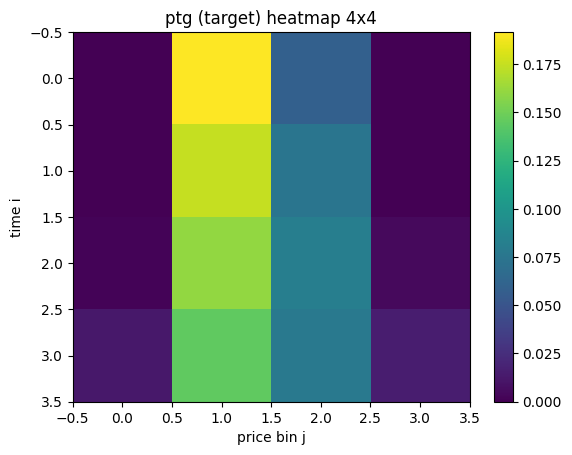

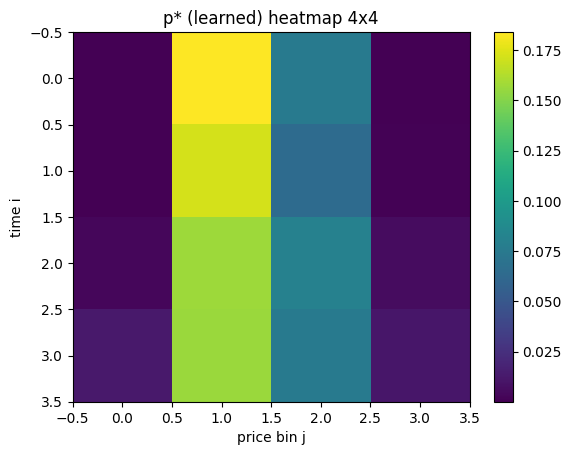

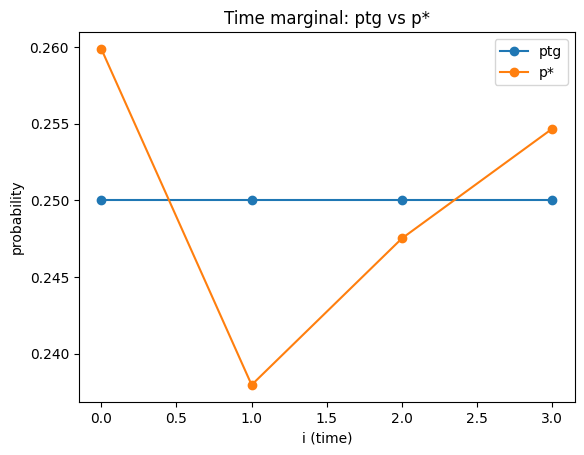

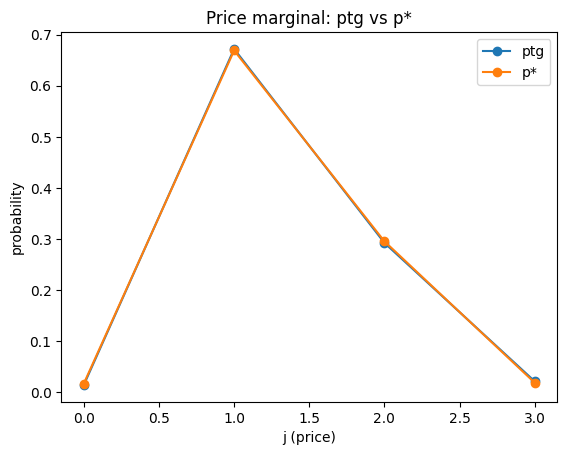

In [40]:
theta_star = res.x
ms = metrics(ptg, p_star)

print("=== BASIC CHECKS ===")
print("sum(ptg)    =", float(np.sum(ptg)))
print("sum(p_star) =", float(np.sum(p_star)))
print("min/max ptg    =", float(np.min(ptg)), float(np.max(ptg)))
print("min/max p_star =", float(np.min(p_star)), float(np.max(p_star)))

print("\n=== 'FIT' METRIC + OTHERS ===")
print("KL(ptg || p*)  =", ms["kl"])
print("L1             =", ms["l1"])
print("TV = 0.5*L1    =", ms["tv"])
print("Linf           =", ms["linf"])

M, N = 4, 4
Ptg_2d = np.asarray(ptg).reshape(M, N)
Pst_2d = np.asarray(p_star).reshape(M, N)

print("\n=== 4x4 MATRICES (rows=t_i, cols=s_j) ===")
print("ptg:")
print(Ptg_2d)
print("\np_star:")
print(Pst_2d)

ptg_time  = Ptg_2d.sum(axis=1)
pst_time  = Pst_2d.sum(axis=1)
ptg_price = Ptg_2d.sum(axis=0)
pst_price = Pst_2d.sum(axis=0)

print("\n=== TIME MARGINAL (sum_j) ===")
print("ptg :", ptg_time)
print("p*  :", pst_time)

print("\n=== PRICE MARGINAL (sum_i) ===")
print("ptg :", ptg_price)
print("p*  :", pst_price)

plt.figure()
plt.title("ptg (target) heatmap 4x4")
plt.imshow(Ptg_2d, aspect="auto")
plt.colorbar()
plt.xlabel("price bin j")
plt.ylabel("time i")
plt.show()

plt.figure()
plt.title("p* (learned) heatmap 4x4")
plt.imshow(Pst_2d, aspect="auto")
plt.colorbar()
plt.xlabel("price bin j")
plt.ylabel("time i")
plt.show()

plt.figure()
plt.title("Time marginal: ptg vs p*")
plt.plot(ptg_time, marker="o", label="ptg")
plt.plot(pst_time, marker="o", label="p*")
plt.xlabel("i (time)")
plt.ylabel("probability")
plt.legend()
plt.show()

plt.figure()
plt.title("Price marginal: ptg vs p*")
plt.plot(ptg_price, marker="o", label="ptg")
plt.plot(pst_price, marker="o", label="p*")
plt.xlabel("j (price)")
plt.ylabel("probability")
plt.legend()
plt.show()
